In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Định nghĩa SASMOTE

In [3]:
class SASMOTE:
    def __init__(self, verbose=True):
        self.verbose = verbose
        self.random_state = 42
        np.random.seed(self.random_state)

    def generate_synthetic_samples(self, X_min_feat, X_min_id, n_to_generate):
        if len(X_min_feat) < 2 or n_to_generate <= 0:
            return np.array([]), np.array([]), np.array([])

        nn = NearestNeighbors(n_neighbors=min(6, len(X_min_feat)))
        nn.fit(X_min_feat)
        _, indices = nn.kneighbors(X_min_feat)

        synthetic_feat = []
        synthetic_user = []
        synthetic_course = []

        generated = 0
        while generated < n_to_generate:
            i = np.random.randint(0, len(X_min_feat))
            neighbors = indices[i][1:]
            if len(neighbors) == 0:
                continue
            j = np.random.choice(neighbors)
            alpha = np.random.uniform(0, 1)
            new_sample = X_min_feat[i] + alpha * (X_min_feat[j] - X_min_feat[i])
            synthetic_feat.append(new_sample)

            # Tạo user_id được sinh ra từ smote
            base_user = X_min_id[i, 0]
            fractional = np.random.uniform(0.000001, 0.999999)
            new_user_id = base_user + fractional

            # course_id copy ngẫu nhiên từ lớp thiểu số
            new_course_id = X_min_id[np.random.randint(0, len(X_min_id)), 1]

            synthetic_user.append(new_user_id)
            synthetic_course.append(new_course_id)
            generated += 1

        return (np.array(synthetic_feat),
                np.array(synthetic_user),
                np.array(synthetic_course))

    def fit_resample(self, df, label_col="label_3"):
        id_cols = ["user_id", "course_id"]
        feature_cols = [c for c in df.columns if c not in id_cols + [label_col]]

        X_id = df[id_cols].values
        X_feat = df[feature_cols].values
        y = df[label_col].values

        classes, counts = np.unique(y, return_counts=True)
        majority_class = classes[np.argmax(counts)]
        majority_count = counts.max()

        print(f"\nNhãn đa số (majority): {int(majority_class)} → {majority_count:,} mẫu")
        print("="*70)

        all_synth_feat = []
        all_synth_id = []
        all_synth_y = []

        for c in classes[counts < majority_count]:
            current_count = counts[classes == c][0]
            n_to_generate = majority_count - current_count
            print(f"Đang xử lý nhãn thiểu số {int(c)} ... (sinh {n_to_generate:,} mẫu)")

            mask = y == c
            X_min_feat = X_feat[mask]
            X_min_id = X_id[mask]

            synth_feat, synth_user, synth_course = self.generate_synthetic_samples(
                X_min_feat, X_min_id, n_to_generate)

            if len(synth_feat) > 0:
                all_synth_feat.append(synth_feat)
                all_synth_id.append(np.column_stack([synth_user, synth_course]))
                all_synth_y.extend([c] * len(synth_feat))

        # Gộp dữ liệu gốc + synthetic
        if all_synth_feat:
            X_feat_final = np.vstack([X_feat] + all_synth_feat)
            X_id_final = np.vstack([X_id] + all_synth_id)
            y_final = np.hstack([y] + all_synth_y)

            added = len(y_final) - len(y)
            print("="*70)
            print(f"Đã sinh thêm {added:,} mẫu synthetic")
            print(f"Tổng mẫu: {len(y):,} → {len(y_final):,}")
        else:
            X_feat_final, X_id_final, y_final = X_feat.copy(), X_id.copy(), y.copy()

        # Tạo DataFrame cuối
        df_final = pd.DataFrame(X_id_final, columns=id_cols)
        df_final = pd.concat([df_final, pd.DataFrame(X_feat_final, columns=feature_cols)], axis=1)
        df_final[label_col] = y_final.astype(int)

        # Sắp lại thứ tự cột
        final_cols = df.columns.tolist()
        df_final = df_final[final_cols]

        return df_final

In [4]:
INPUT_FILE = "/content/drive/MyDrive/Nhóm 1/Dataset/Data_cleaned/split_data/data_median_im_3/train_us.csv"
LABEL_COL = "label_3"

df = pd.read_csv(INPUT_FILE)
df

,user_id,course_id,course_duration,start_year,start_month,start_day,enrollment_to_end,label_3,gender,num_course_order,...,cmt_p4_max_comment_length_phase4,cmt_p4_text_diversity_phase4,cmt_p4_comment_days_active_phase4,cmt_p4_entropy_time_mean_phase4,cmt_p4_most_common_time_bin_phase4,cmt_p4_time_entropy_var_phase4,cmt_p4_positive_ratio_phase4,cmt_p4_neutral_ratio_phase4,cmt_p4_negative_ratio_phase4,cmt_p4_sentiment_entropy_phase4
0,499264,633,250,2019,12,25,194,2,1.0,3,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
1,112819,869,121,2020,4,1,112,2,0.0,51,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
2,606920,714,121,2020,9,1,100,2,1.0,4,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
3,556258,792,173,2020,2,9,150,2,1.0,20,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
4,846799,833,93,2020,4,13,46,2,2.0,1,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206617,178425,847,104,2020,4,13,28,2,2.0,1,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
206618,1096149,777,137,2020,2,14,64,2,2.0,9,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
206619,429165,814,169,2020,2,13,146,2,1.0,19,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
206620,1124303,845,77,2019,12,29,75,2,1.0,1,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0


# Chạy SASMOTE

In [5]:
print(f"Phân bố label trước SASMOTE:")
print(df[LABEL_COL].value_counts().sort_index())

sasmote = SASMOTE(verbose=True)
df_balanced = sasmote.fit_resample(df, label_col=LABEL_COL)

print(f"\nPhân bố label sau SASMOTE:")
print(df_balanced[LABEL_COL].value_counts().sort_index())

Phân bố label trước SASMOTE:
label_3
0      1783
1      4839
2    200000
Name: count, dtype: int64

Nhãn đa số (majority): 2 → 200,000 mẫu
Đang xử lý nhãn thiểu số 0 ... (sinh 198,217 mẫu)
Đang xử lý nhãn thiểu số 1 ... (sinh 195,161 mẫu)
Đã sinh thêm 393,378 mẫu synthetic
Tổng mẫu: 206,622 → 600,000

Phân bố label sau SASMOTE:
label_3
0    200000
1    200000
2    200000
Name: count, dtype: int64


In [6]:
OUTPUT_FILE = "/content/drive/MyDrive/Nhóm 1/Dataset/Data_cleaned/split_data/data_median_sasmote/train_median_sasmote.csv"

df_balanced.to_csv(OUTPUT_FILE, index=False)

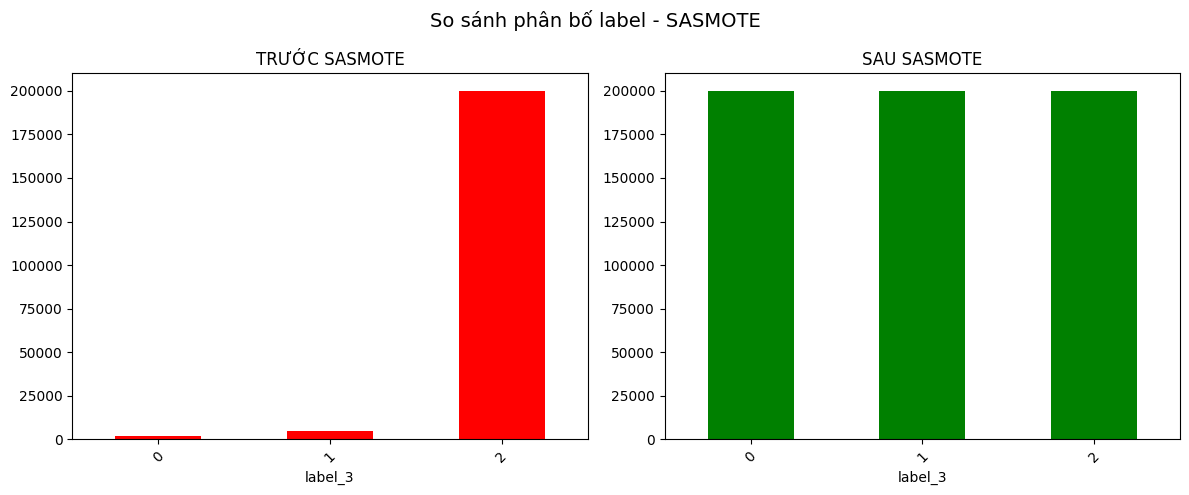

In [7]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="TRƯỚC SASMOTE", color='red')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
df_balanced[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="SAU SASMOTE", color='green')
plt.xticks(rotation=45)

plt.suptitle("So sánh phân bố label - SASMOTE", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
df_final = pd.read_csv("/content/drive/MyDrive/Nhóm 1/Dataset/Data_cleaned/split_data/data_median_sasmote/train_median_sasmote.csv")
df_final

,user_id,course_id,course_duration,start_year,start_month,start_day,enrollment_to_end,label_3,gender,num_course_order,...,cmt_p4_max_comment_length_phase4,cmt_p4_text_diversity_phase4,cmt_p4_comment_days_active_phase4,cmt_p4_entropy_time_mean_phase4,cmt_p4_most_common_time_bin_phase4,cmt_p4_time_entropy_var_phase4,cmt_p4_positive_ratio_phase4,cmt_p4_neutral_ratio_phase4,cmt_p4_negative_ratio_phase4,cmt_p4_sentiment_entropy_phase4
0,499264.000000,633.0,250.0,2019.0,12.0,25.0,194.000000,2,1.000000,3.0,...,8.0,33.000000,1.000000,0.615991,31.000000,0.0,0.000000,0.818182,0.0,0.000000
1,112819.000000,869.0,121.0,2020.0,4.0,1.0,112.000000,2,0.000000,51.0,...,8.0,33.000000,1.000000,0.615991,31.000000,0.0,0.000000,0.818182,0.0,0.000000
2,606920.000000,714.0,121.0,2020.0,9.0,1.0,100.000000,2,1.000000,4.0,...,8.0,33.000000,1.000000,0.615991,31.000000,0.0,0.000000,0.818182,0.0,0.000000
3,556258.000000,792.0,173.0,2020.0,2.0,9.0,150.000000,2,1.000000,20.0,...,8.0,33.000000,1.000000,0.615991,31.000000,0.0,0.000000,0.818182,0.0,0.000000
4,846799.000000,833.0,93.0,2020.0,4.0,13.0,46.000000,2,2.000000,1.0,...,8.0,33.000000,1.000000,0.615991,31.000000,0.0,0.000000,0.818182,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,867366.194870,846.0,165.0,2020.0,2.0,17.0,49.858887,1,2.000000,1.0,...,6.0,49.846678,1.141113,0.420590,33.435548,0.0,0.070556,0.929444,0.0,0.097812
599996,525144.532773,749.0,165.0,2020.0,2.0,17.0,160.024522,1,0.802452,1.0,...,8.0,33.000000,1.000000,0.615991,31.000000,0.0,0.000000,0.818182,0.0,0.000000
599997,17891.754214,777.0,169.0,2020.0,2.0,13.0,158.162705,1,1.367459,2.0,...,8.0,33.000000,1.000000,0.615991,31.000000,0.0,0.000000,0.818182,0.0,0.000000
599998,401298.112453,708.0,152.0,2019.0,12.0,31.0,85.000000,1,1.000000,1.0,...,8.0,33.000000,1.000000,0.615991,31.000000,0.0,0.000000,0.818182,0.0,0.000000
